# Monte Carlo Control in a Windy GridWorld

## Problem

An agent must learn to navigate in a 5x5 grid from bottom-left corner (0, 0) to the top-right corner (4, 4). At each step, it chooses one of four actions [up, down, left, right], moving one cell in the chosen direction.

## Environment

- **Wind**: at each agent's movement, wind may push the agent in some direction with different magnitudes, depending on the specific implementation.
- **Walls**: the agent cannot exit the grid; when it hits a wall (i.e. its position results outside the grid), it is clipped back into the grid and suffers a penalty.
- **Rewards**: +1 for reaching the goal, -0.1 for hitting a wall, 0 otherwise.
- **Episodes**: an episode ends when the agent reaches the goal, or after 200 steps. The discount factor is $\gamma = 0.9$.

## Code

### Classes for both approaches

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time as time
from tqdm import trange
from itertools import product
from typing import NamedTuple
from typing import Optional
from pathlib import Path
from enum import StrEnum
from matplotlib.patches import Circle
from abc import ABC, abstractmethod

BOARD_SIZE = 5

class GridState(NamedTuple):
    row: int
    col: int

    # it's useful to add GridStates automatically
    def __add__(self, other: object) -> 'GridState':
        if isinstance(other, GridState):
            return GridState(self.row + other.row, self.col + other.col)
        elif isinstance(other, tuple) and len(other) == 2:
            return GridState(self.row + other[0], self.col + other[1])
        raise NotImplementedError

    def is_valid(self, board_size: int = BOARD_SIZE) -> bool:
        """Checks if the state lies within the valid board grid"""
        return 0 <= self.row < board_size and 0 <= self.col < board_size

    def clip(self, board_size: int = BOARD_SIZE) -> 'GridState':
        """Clips the coordinates within [0, board_size - 1]"""
        clipped_row = max(0, min(self.row, board_size - 1))
        clipped_col = max(0, min(self.col, board_size - 1))
        return GridState(row = clipped_row, col = clipped_col)

    @property
    def idx(self) -> tuple[int, int]:
        return (self.row, self.col)

class Action(StrEnum):
    UP = 'up'
    DOWN = 'down'
    LEFT = 'left'
    RIGHT = 'right'

    @property
    def delta(self) -> GridState:
        """Returns the (row, col) shift for this action"""
        match self:
            case Action.UP:     return GridState(1, 0)
            case Action.DOWN:   return GridState(-1, 0)
            case Action.LEFT:   return GridState(0, -1)
            case Action.RIGHT:  return GridState(0, 1)
    @property
    def idx(self) -> int:
        """Returns the numerical index of the action for Q-table lookup."""
        match self:
            case Action.UP:     return 0
            case Action.DOWN:   return 1
            case Action.LEFT:   return 2
            case Action.RIGHT:  return 3
    @classmethod
    def from_idx(cls, idx: int) -> "Action":
        """Converts an integer index back to its corresponding Action enum."""
        assert(0 <= idx < 4)
        return list(cls)[idx]

In [2]:
class Estimator(ABC):
    """
        Tabular estimator: this is the basis for value and 
        action-value functions in tabular form.
    """
    def __init__(
            self,
            shape: tuple[int, ...],
            size = BOARD_SIZE,
            gamma = 0.9,
            alpha: Optional[float] = None,  
    ):
        self.values, self.counts = np.zeros(shape), np.zeros(shape, dtype = int)
        self.gamma, self.alpha, self.size = gamma, alpha, size
        self._step = (self._sample_average_update if alpha is None
                      else self._constant_alpha_update)

    def _sample_average_update(self, key: tuple[int, ...], target: float) -> None:
            self.counts[key] += 1
            self.values[key] += (target - self.values[key]) / self.counts[key]
    
    def _constant_alpha_update(self, key: tuple[int, ...], target: float) -> None:
        self.counts[key] += 1
        self.values[key] += (target - self.values[key]) * self.alpha

    def update(self, key: tuple[int, ...], target: float) -> None:
        self._step(key, target)
    
    @staticmethod
    @abstractmethod
    def get_key(s: GridState, a: Action) -> tuple[int, ...]:
        """Table index for this (state, action); a state-only table ignores a."""
        pass

class Value(Estimator):
    """State-value table V(s), indexed by [row, col]."""
    def __init__(self, size = BOARD_SIZE, **kwargs):
        super().__init__(shape = (size, size), size = size, **kwargs)

    @staticmethod
    def get_key(s: GridState, a: Action): return s.idx

    def draw(self, save_to: Optional[str] = None):
        fig, ax = plt.subplots()
        # Create a color map based on the value grid
        cax = ax.imshow(self.values, cmap='coolwarm', origin='lower', 
                        extent=(0, self.size, 0, self.size), vmin = -0.5, vmax = 1.0)
        # Add a color bar to indicate value levels
        fig.colorbar(cax)
        # Draw grid lines
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black', lw=0.5)
            ax.plot([i, i], [0, self.size], color='black', lw=0.5)
        # Add coordinates and values inside the grid in the top-right corner of each cell
        for i, j in product(range(self.size), repeat = 2):
            val = self.values[i, j] # i = row, j = col
            ax.text(j + 0.9, i + 0.9, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')
            # Optionally display the value itself at the center of the cell
            ax.text(j + 0.5, i + 0.5, f"{val:.2f}", fontsize=8, color='black', ha='center', va='center')
        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        if save_to is not None:
            Path(save_to).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_to, dpi=150, bbox_inches="tight")
        plt.show()

class ActionValue(Estimator):
    """Action-value table Q(s, a), indexed by [row, col, action]."""
    def __init__(self, size = BOARD_SIZE, **kwargs):
        super().__init__(shape = (size, size, len(Action)), size = size, **kwargs)

    @staticmethod
    def get_key(s: GridState, a: Action): return (*s.idx, a.idx)

In [3]:
class Policy(ABC):
    def __init__(self, action_value: ActionValue, size = BOARD_SIZE):
        self.size = size
        self.action_value = action_value

    @abstractmethod
    def act(self, s: GridState) -> Action:
        pass
    
class EpsilonSoftPolicy(Policy):
    def __init__(self, 
                 action_value: ActionValue,
                 epsilon = 0.1,
                 decay = 1.0,
                 min_epsilon = 0.01,
                 size = BOARD_SIZE):
        super().__init__(action_value, size = size)
        self.epsilon, self.decay, self.min_epsilon = epsilon, decay, min_epsilon

    def get_action_probabilities(self, s: GridState) -> np.ndarray[float]:
        """
        Returns a probability array over all actions for state s under the 
        epsilon-soft policy.
        """
        probs = np.full(len(Action), self.epsilon / len(Action))
        Q_s = self.action_value.values[s.idx]
        max_q = np.max(Q_s)
        best_action_idxs = np.flatnonzero(Q_s == max_q)
        # add the remaining (1 - epsilon) weight equally among all best actions
        probs[best_action_idxs] += (1.0 - self.epsilon) / len(best_action_idxs)
        return probs

    def act(self, s: GridState) -> Action:
        probs = self.get_action_probabilities(s)
        chosen_idx = np.random.choice(len(probs), p = probs)
        return Action.from_idx(chosen_idx)
    
    def decay_epsilon(self) -> None:
        self.epsilon = max(self.min_epsilon, self.epsilon * self.decay)    

In [ ]:
class GridEnvironment:
    """Standard GridEnvironment without wind."""
    def __init__(self, size = BOARD_SIZE):
        self.state = GridState(0, 0) # start in bottom-left corner
        self.size = size
        self.goal = GridState(size - 1, size - 1)

    def wind(self, action: Action) -> GridState:
        return GridState(0, 0)  # no wind at all

    def move(self, action: Action) -> tuple[GridState, float, bool]:
        self.state += self.wind(action) + action.delta
        hit_wall: bool = not self.state.is_valid()
        self.state = self.state.clip()
        done: bool = self.state == self.goal
        reward: float = int(done) - hit_wall * 0.1
        return self.state, reward, done

    def reset(self) -> GridState:
        self.state = GridState(0, 0)
        return self.state

    def generate_episode(self, policy: Policy, s: GridState, max_steps: int = 200):
        for _ in range(max_steps):
            a = policy.act(s)
            next_s, r, done = self.move(a)
            yield s, a, r
            if done: break
            s = next_s

    def draw(self):
        fig, ax = plt.subplots()
        # Draw grid
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black')
            ax.plot([i, i], [0, self.size], color='black')
        # Add coordinates inside the grid in the top-right corner of each cell
        for i, j in product(range(self.size), repeat = 2):
            ax.text(j + 0.95, i + 0.95, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')
        # Draw goal (circle)
        ax.add_patch(Circle((self.goal.col + 0.5, self.goal.row + 0.5), 0.3, color = 'red', label = 'Goal'))
        # Draw player (circle)
        ax.add_patch(Circle((self.state.col + 0.5, self.state.row + 0.5), 0.3, color = 'blue', label = 'Player'))
        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        plt.show()  


class StochasticWindGridEnvironment(GridEnvironment):
    """GridEnvironment with stochastic wind, i.e. wind has a probability to push the player at each step."""
    def __init__(self, size = BOARD_SIZE, prob = 0.9):
        super().__init__(size)
        self.prob = prob
    
    def wind(self, action: Action) -> GridState:
        if np.random.rand() >= self.prob: return GridState(0, 0) # no wind
        row, col = self.state
        match (row % 2, col % 2):
            case (0, 0): return GridState(0, np.random.choice([-2, -1, 1]))
            case (0, 1): return GridState(np.random.choice([-1, 1, 2]), 0)
            case (1, 0): return GridState(np.random.choice([-2, -1, 1]), 0)
            case _:      return GridState(0, np.random.choice([-1, 1, 2]))

In [5]:
NUM_EPISODES = 5000

class Agent(ABC):
    """
        Agent that encapsulates a EpsilonSoftPolicy and ActionValue estimator
        to run prediction and control. The specific strategy to be used is decided 
        by the subclasses.
    """
    def __init__(self,
                 env: GridEnvironment,
                 initial_action_value: Optional[ActionValue] = None,
                 alpha: Optional[float] = None,
                 epsilon: float = 0.1,
                 decay: float = 0.999):
        self.env = env
        self.action_value = (initial_action_value 
                             if initial_action_value is not None 
                             else ActionValue(alpha = alpha))
        self.policy = EpsilonSoftPolicy(self.action_value, epsilon = epsilon, decay = decay)
        self.alpha = alpha

    @abstractmethod
    def _step_evaluate(self, V: Value) -> None:
        pass

    @abstractmethod
    def _step_training(self) -> float:
        pass

    def evaluate(self,
                 initial_value: Optional[Value] = None,
                 num_episodes = NUM_EPISODES) -> Value:
        V = initial_value if initial_value is not None else Value(alpha = self.alpha)
        for _ in trange(num_episodes): self._step_evaluate(V)
        return V


    def train(self, num_episodes = NUM_EPISODES) -> list[float]:
        returns_history = []
        for _ in trange(num_episodes): returns_history.append(self._step_training())
        return returns_history

### Approach: Monte Carlo

We use tabular Monte Carlo methods (both prediction and control, where exploration is ensured through $\epsilon$-soft policies), which learn from complete episodes. The algorithms used are in the following images:

![MC prediction](https://i.imgur.com/jQW04aG.png)

![MC control](https://i.imgur.com/0sz7irr.png)

*Algorithm boxes: R. S. Sutton and A. G. Barto, Reinforcement Learning: An Introduction, 2nd ed. (2018), Sections 5.1 and 5.4.*

In [6]:
class MCAgent(Agent):
    """
        Agent that encapsulates an EpsilonSoftPolicy and ActionValue estimator
        to run Monte Carlo Control and Prediction.
    """
    def __init__(self, *args, use_first_visit = True, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_first_visit = use_first_visit

    @staticmethod
    def _returns(rewards, gamma) -> list[float]:
        G, returns = 0.0, []
        for r in reversed(rewards):
            G = gamma * G + r
            returns.append(G)
        return returns[::-1]

    def _update_table(self, table: Estimator, trajectory, actions, rewards) -> None:
        returns = self._returns(rewards, table.gamma)
        seen: set[tuple[int, ...]] = set()
        for s, a, g in zip(trajectory, actions, returns):
            key = table.get_key(s, a)
            if self.use_first_visit:
                if key in seen: continue
                seen.add(key)
            table.update(key, g)

    def _generate_trajectory(self) -> tuple[list[GridState], list[Action], list[float]]:
        """
        Generates a trajectory for the environment.
        
        Returns:
            trajectory: list of states visited
            actions:    list of actions performed
            rewards:    list of rewards obtained
        """
        s = self.env.reset()
        steps = self.env.generate_episode(self.policy, s)
        trajectory, actions, rewards = zip(*steps)
        return list(trajectory), list(actions), list(rewards) 

    def _step_evaluate(self, V: Value) -> None:
        self._update_table(V, *self._generate_trajectory())

    def _step_training(self) -> float:
        trajectory, actions, rewards = self._generate_trajectory()
        self._update_table(self.action_value, trajectory, actions, rewards)
        self.policy.decay_epsilon()
        return sum(rewards)

100%|██████████| 5000/5000 [01:00<00:00, 82.36it/s] 


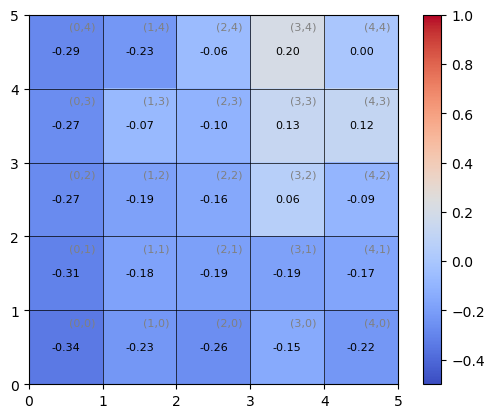

In [7]:
OUTPUT_FOLDER = 'figures/'
mc_agent = MCAgent(StochasticWindGridEnvironment())
mc_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'MC_evaluate_before_training.png')

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:08<00:00, 611.34it/s]


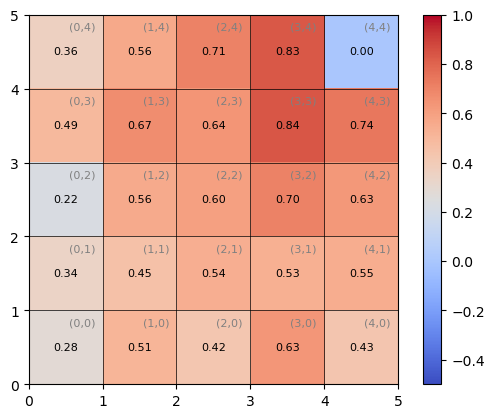

In [8]:
mc_returns = mc_agent.train()
mc_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'MC_evaluate_after_training.png')

### Approach: TD(0)

We use tabular TD(0) methods (both prediction and control, where exploration is ensured throug $\epsilon$-soft policies), which learn step-by-step. The algorithms used are in the following images:


![TD(0) prediction](https://i.imgur.com/SD9xaEx.png)

![TD(0) control Q-learning](https://i.imgur.com/WNAE8rH.png)

*Algorithm boxes: R. S. Sutton and A. G. Barto, Reinforcement Learning: An Introduction, 2nd ed. (2018), Sections 6.1 and 6.5.*


In [ ]:
class TD0Agent(Agent, ABC):
    """
        Agent that encapsulates an EpsilonSoftPolicy and ActionValue estimator
        to run TD(0) Control and Prediction.
        Subclasses must decided what bootstrap value to use in the update.
    """
    def __init__(self, *args, alpha: float = 0.1, **kwargs):
        assert(alpha is not None and 0 < alpha < 1)     # must use alpha here
        super().__init__(*args, alpha = alpha, **kwargs)

    @abstractmethod
    def _bootstrap_value(self, next_s: GridState) -> float:
        """Compues the bootstrap value for next_s."""
        pass

    def _step_evaluate(self, V: Value, max_steps: int = 200) -> None:
        s = self.env.reset()
        for _ in range(max_steps):
            a = self.policy.act(s)
            next_s, r, done = self.env.move(a)
            target = r + (0.0 if done else V.gamma * V.values[next_s.idx])
            V.update(V.get_key(s, a), target)
            if done: break
            s = next_s
    
    def _step_training(self, max_steps: int = 200) -> float:
        s = self.env.reset()
        total = 0.0
        for _ in range(max_steps):
            a = self.policy.act(s)
            next_s, r, done = self.env.move(a)
            target = r + (0.0 if done 
                          else self.action_value.gamma * self._bootstrap_value(next_s))
            self.action_value.update(self.action_value.get_key(s, a), target)
            total += r
            if done: break
            s = next_s
        self.policy.decay_epsilon()
        return total

class QLearningAgent(TD0Agent):
    def _bootstrap_value(self, next_s: GridState) -> float:
        # max_a Q(next_s, a)
        return np.max(self.action_value.values[next_s.idx])
        
class ExpectedSarsaAgent(TD0Agent):
    def _bootstrap_value(self, next_s: GridState) -> float:
        # sum[pi(next_s | a) * Q(next_s, a)] over all possible actions a's
        probs = self.policy.get_action_probabilities(next_s)
        Q_s = self.action_value.values[next_s.idx]
        return np.dot(probs, Q_s)

100%|██████████| 5000/5000 [00:51<00:00, 97.26it/s] 


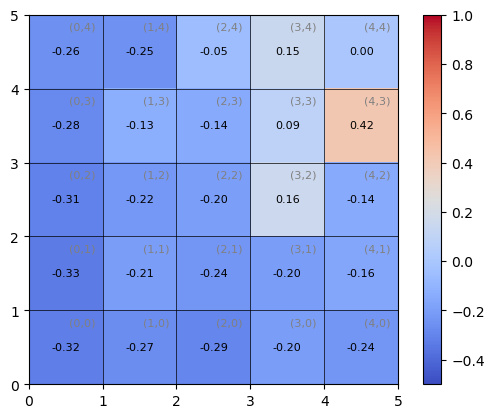

In [10]:
td_agent = QLearningAgent(StochasticWindGridEnvironment())
td_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'TD0_evaluate_before_training.png')

100%|██████████| 5000/5000 [00:06<00:00, 741.00it/s]


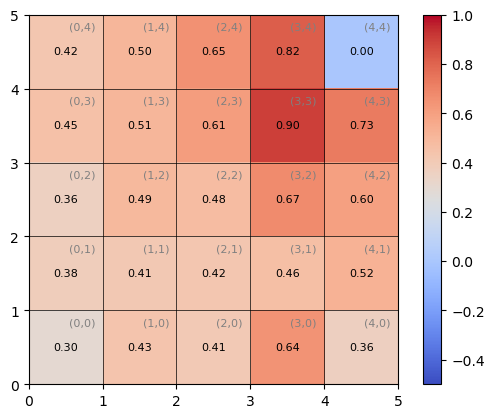

In [11]:
td_returns = td_agent.train()
td_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'TD0_evalute_after_training.png')

### Comparing the returns

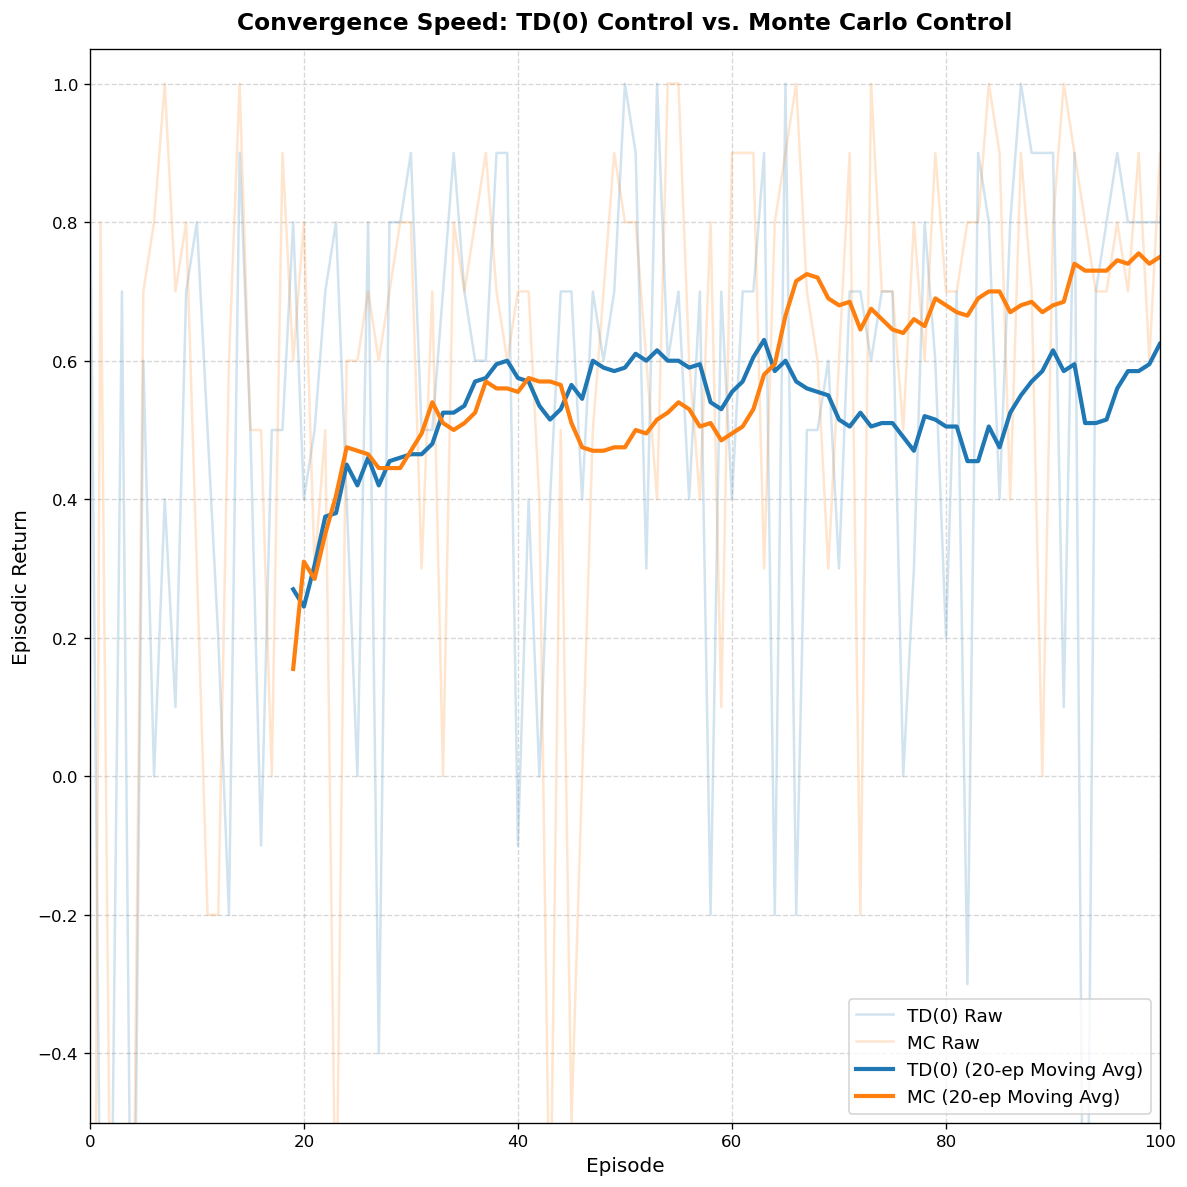

In [12]:
# a script to compare the returns of MC and TD(0): this is useful for 
# understanding the difference in the convergence speed.
WINDOW_SIZE = 20
def moving_average(data, window = WINDOW_SIZE):
    weights = np.ones(window) / window
    return np.convolve(data, weights, mode='valid')

td_smooth = moving_average(td_returns)
mc_smooth = moving_average(mc_returns)
x_smoothed = np.arange(WINDOW_SIZE - 1, len(td_returns))
plt.figure(figsize = (10, 10), dpi = 120)
plt.plot(td_returns, color = '#1f77b4', alpha=0.2, label='TD(0) Raw')
plt.plot(mc_returns, color = '#ff7f0e', alpha=0.2, label='MC Raw')
plt.plot(x_smoothed, td_smooth, color = '#1f77b4', linewidth=2.5, label=f'TD(0) ({WINDOW_SIZE}-ep Moving Avg)')
plt.plot(x_smoothed, mc_smooth, color = '#ff7f0e', linewidth=2.5, label=f'MC ({WINDOW_SIZE}-ep Moving Avg)')
plt.xlim(0, 100)        # zoom in on the early episodes
plt.ylim(-0.5, 1.05)    # droput extreme outliers  
plt.title('Convergence Speed: TD(0) Control vs. Monte Carlo Control', fontsize = 14, fontweight = 'bold', pad = 12)
plt.xlabel('Episode', fontsize = 12)
plt.ylabel('Episodic Return', fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend(loc = 'lower right', fontsize = 11)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'convergence_comparison.png', dpi = 300)
plt.show()

TD(0) gets to decent results quickly.

### Expected SARSA for the love of the game

100%|██████████| 5000/5000 [00:43<00:00, 114.40it/s]


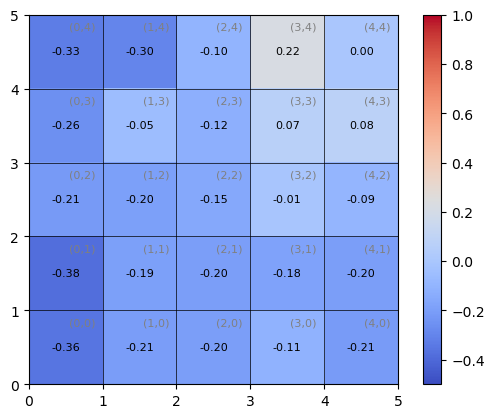

In [13]:
expected_sarsa_agent = ExpectedSarsaAgent(StochasticWindGridEnvironment())
expected_sarsa_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'ExpectedSARSA_before_training.png')

100%|██████████| 5000/5000 [00:06<00:00, 714.88it/s]


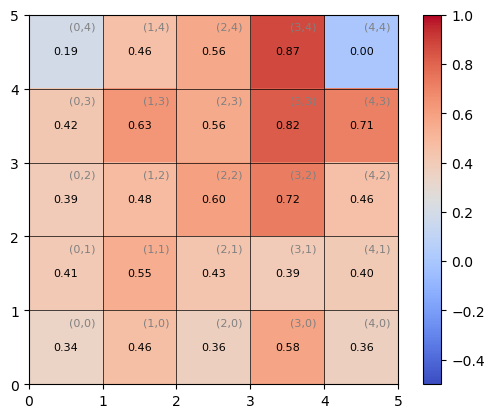

In [14]:
expected_sarsa_returns = expected_sarsa_agent.train()
expected_sarsa_agent.evaluate().draw(save_to = OUTPUT_FOLDER + 'ExpectedSARSA_after_training.png')

In [15]:
results = {
    'Monte Carlo'       : mc_returns,
    'Q-learning'        : td_returns,
    'Expected SARSA'    : expected_sarsa_returns
}
print(f"{'Agent Strategy':<20} | {'Mean Return':>12} | {'Std Dev':>10}")
print("-" * 48)
for name, returns in results.items():
    print(f'{name:<20} | {np.mean(returns):>12.2f} | {np.std(returns):>10.2f}')

Agent Strategy       |  Mean Return |    Std Dev
------------------------------------------------
Monte Carlo          |         0.82 |       0.18
Q-learning           |         0.79 |       0.16
Expected SARSA       |         0.80 |       0.13


MC has higher variance, as expected. Moreover, since Expected SARSA takes an expectation over all possible next actions (rather than sampling a single action, like SARSA), it achieves the lowest variance.